<a href="https://colab.research.google.com/github/Fzzrr/retail-forecasting-application/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import kagglehub

path = kagglehub.dataset_download("anirudhchauhan/retail-store-inventory-forecasting-dataset")

print('Path to dataset:', path)

Using Colab cache for faster access to the 'retail-store-inventory-forecasting-dataset' dataset.
Path to dataset: /kaggle/input/retail-store-inventory-forecasting-dataset


In [ ]:
import os

files = os.listdir(path)
print('Files in dataset:', files)

Files in dataset: ['retail_store_inventory.csv']


In [ ]:
file_name = files[0]
full_path = os.path.join(path, file_name)

df = pd.read_csv(full_path)
print('Dataset loaded successfully!')
print('First 5 rows of the dataset:')
df.head(5)

Dataset loaded successfully!
First 5 rows of the dataset:


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [ ]:
df.drop(columns=['Store ID', 'Product ID', 'Region', 'Demand Forecast'], inplace=True)
df.head(5)

,Date,Category,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,Groceries,231,127,55,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,Toys,204,150,66,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,Toys,102,65,51,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,Toys,469,61,164,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,Electronics,166,14,135,73.64,0,Sunny,0,68.95,Summer


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cols = ['Category', 'Weather Condition', 'Seasonality']
for col in cols:
    df[col] = le.fit_transform(df[col])
df.head(5)

,Date,Category,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,3,231,127,55,33.50,20,1,0,29.69,0
1,2022-01-01,4,204,150,66,63.01,20,3,0,66.16,0
2,2022-01-01,4,102,65,51,27.99,10,3,1,31.32,2
3,2022-01-01,4,469,61,164,32.72,10,0,1,34.74,0
4,2022-01-01,1,166,14,135,73.64,0,3,0,68.95,2


In [ ]:
# 3. Agregasi: Kelompokkan berdasarkan 'Date' dan 'Category'
# Di sini kita tentukan kolom mana yang ingin di-SUM dan mana yang di-MEAN

df['Date'] = pd.to_datetime(df['Date'])  # Pastikan kolom 'Date' dalam format datetime

df_hasil = df.groupby(['Date', 'Category']).agg({
    'Units Sold': 'mean',          # Total penjualan harian per kategori
    'Inventory Level': 'mean',    # Rata-rata stok harian
    'Units Ordered': 'mean',       # Total pesanan stok baru
    'Price': 'mean',              # Rata-rata harga di kategori tersebut
    # 'Demand Forecast': 'mean',    # Rata-rata prediksi permintaan
    'Holiday/Promotion': 'mean',   # 1 jika ada promo, 0 jika tidak (mengambil nilai tertinggi)
    'Seasonality': 'mean'         # Rata-rata nilai seasonality
}).reset_index()                  # WAJIB: Agar 'Date' dan 'Category' kembali jadi kolom

df_hasil[['Holiday/Promotion', 'Seasonality']] = df_hasil[['Holiday/Promotion', 'Seasonality']].round(0).astype(int)

# 4. Menampilkan Hasil
print("Hasil Kalkulasi Per Hari Berdasarkan Kategori:")
df_hasil.head()

Hasil Kalkulasi Per Hari Berdasarkan Kategori:


,Date,Category,Units Sold,Inventory Level,Units Ordered,Price,Holiday/Promotion,Seasonality
0,2022-01-01,0,172.000000,296.363636,100.000000,56.236818,0,2
1,2022-01-01,1,156.363636,292.227273,104.500000,56.444545,0,1
2,2022-01-01,2,144.833333,286.166667,125.666667,56.090833,1,2
3,2022-01-01,3,135.304348,308.347826,103.739130,62.486087,1,2
4,2022-01-01,4,114.761905,235.666667,120.380952,55.348095,1,2


In [ ]:
# 1. Pastikan kolom Date sudah bertipe datetime (Penting!)
df_hasil['Date'] = pd.to_datetime(df_hasil['Date'])

# 2. Set kolom 'Date' menjadi index
df_hasil = df_hasil.set_index('Date')

df_hasil.head()

,Category,Units Sold,Inventory Level,Units Ordered,Price,Holiday/Promotion,Seasonality
Date,,,,,,,
2022-01-01,0,172.000000,296.363636,100.000000,56.236818,0,2
2022-01-01,1,156.363636,292.227273,104.500000,56.444545,0,1
2022-01-01,2,144.833333,286.166667,125.666667,56.090833,1,2
2022-01-01,3,135.304348,308.347826,103.739130,62.486087,1,2
2022-01-01,4,114.761905,235.666667,120.380952,55.348095,1,2


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ['Units Sold', 'Inventory Level', 'Units Ordered', 'Price', 'Holiday/Promotion', 'Seasonality']
df_hasil[cols] = scaler.fit_transform(df_hasil[cols])
df_hasil.head()

,Category,Units Sold,Inventory Level,Units Ordered,Price,Holiday/Promotion,Seasonality
Date,,,,,,,
2022-01-01,0,0.642933,0.589735,0.393796,0.534601,0.0,1.0
2022-01-01,1,0.554310,0.571044,0.445374,0.539587,0.0,0.0
2022-01-01,2,0.488960,0.543657,0.687983,0.531097,1.0,1.0
2022-01-01,3,0.434952,0.643890,0.436653,0.684605,1.0,1.0
2022-01-01,4,0.318523,0.315457,0.627399,0.513269,1.0,1.0


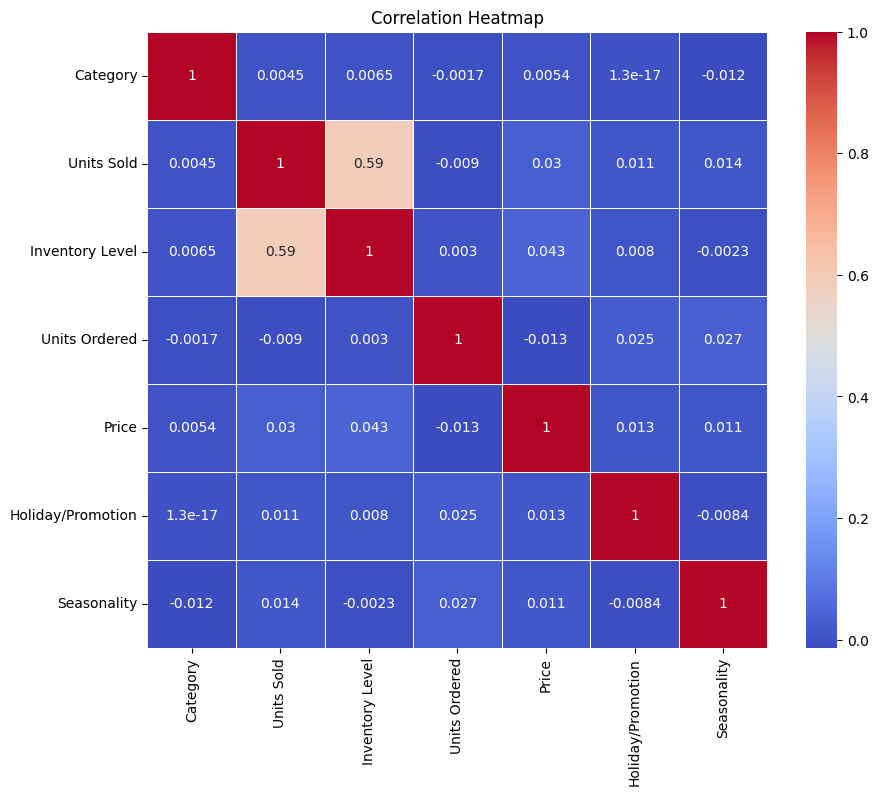

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Contoh: Heatmap korelasi antar fitur
plt.figure(figsize=(10, 8))
sns.heatmap(df_hasil.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import numpy as np

df_normalized = df_hasil.copy()  # Pastikan df_hasil sudah dalam bentuk yang benar dan terurut

# Asumsi nama dataframe kamu adalah df_normalized
# 1. Filter hanya untuk Kategori 0
df_cat0 = df_normalized[df_normalized['Category'] == 0].copy()

# 2. Buang kolom Category karena sudah tidak diperlukan untuk input model
df_cat0 = df_cat0.drop(columns=['Category'])

# Sekarang kolom datanya berurutan:
# [0] Units Sold, [1] Inventory Level, [2] Units Ordered, [3] Price, [4] Holiday, [5] Seasonality
print("Kolom yang tersisa:", df_cat0.columns.tolist())

# 3. Ubah dataframe menjadi bentuk array NumPy (syarat mutlak untuk TensorFlow/Keras)
data_array = df_cat0.values

Kolom yang tersisa: ['Units Sold', 'Inventory Level', 'Units Ordered', 'Price', 'Holiday/Promotion', 'Seasonality']


In [ ]:
def create_sequences(data, target_cols_indices, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        # X berisi semua kolom (fitur) selama 30 hari
        X.append(data[i:(i + window_size), :])
        # y hanya berisi kolom target (Units Sold & Inventory Level) di hari ke-31
        y.append(data[i + window_size, target_cols_indices])
    return np.array(X), np.array(y)

# Eksekusi pembuatan sekuens
window_size = 30
target_indices = [1, 2] # Indeks kolom Units Sold dan Inventory Level di data_array

X, y = create_sequences(data_array, target_indices, window_size)

print(f"Bentuk Input (X): {X.shape}") # Akan menghasilkan (jumlah_baris, 30, 6)
print(f"Bentuk Target (y): {y.shape}") # Akan menghasilkan (jumlah_baris, 2)

Bentuk Input (X): (701, 30, 6)
Bentuk Target (y): (701, 2)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Split Data (80% Train, 20% Test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 2. Bangun Arsitektur LSTM
model = Sequential()
# Layer Input & LSTM 1
model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=(window_size, X_train.shape[2])))
model.add(Dropout(0.2))
# Layer LSTM 2
model.add(LSTM(32, activation='relu'))
model.add(Dropout(0.2))
# Layer Output: 2 neuron untuk memprediksi 2 target sekaligus
model.add(Dense(2))

# 3. Compile dan Training
model.compile(optimizer='adam', loss='mse')

print("Memulai proses training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)
print("Training selesai!")

Memulai proses training...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.1003 - val_loss: 0.0229
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0321 - val_loss: 0.0219
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0305 - val_loss: 0.0236
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0296 - val_loss: 0.0207
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0278 - val_loss: 0.0229
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0266 - val_loss: 0.0209
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0256 - val_loss: 0.0203
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0267 - val_loss: 0.0214
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0243 - val_loss: 0.0217
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0261 - val_loss: 0.0213
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0242 - val_loss: 0.0203
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0231 - val_l

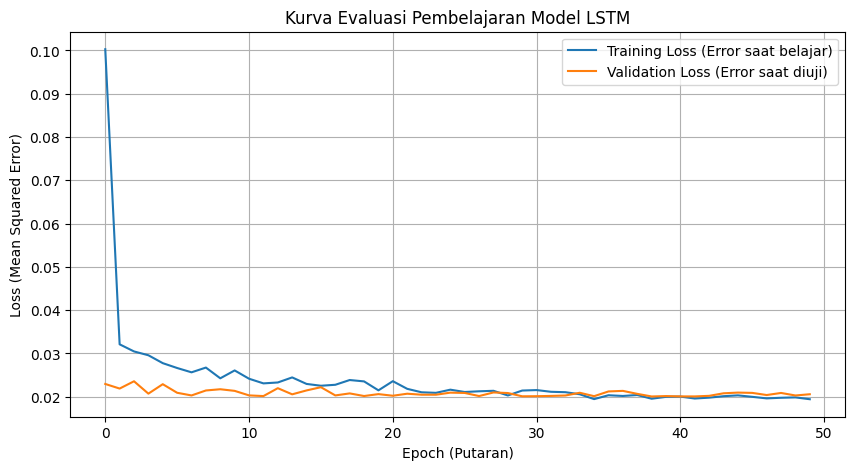

In [ ]:
import matplotlib.pyplot as plt

# Membuat grafik plot dari history training
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (Error saat belajar)')
plt.plot(history.history['val_loss'], label='Validation Loss (Error saat diuji)')
plt.title('Kurva Evaluasi Pembelajaran Model LSTM')
plt.xlabel('Epoch (Putaran)')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Meminta model menebak data test
y_pred = model.predict(X_test)

# Menghitung Error untuk Target 1: Units Sold (Indeks 0)
mae_units = mean_absolute_error(y_test[:, 0], y_pred[:, 0])
rmse_units = np.sqrt(mean_squared_error(y_test[:, 0], y_pred[:, 0]))

# Menghitung Error untuk Target 2: Inventory Level (Indeks 1)
mae_inv = mean_absolute_error(y_test[:, 1], y_pred[:, 1])
rmse_inv = np.sqrt(mean_squared_error(y_test[:, 1], y_pred[:, 1]))

print("=== Evaluasi Model (Skala Normalisasi 0-1) ===")
print(f"[Units Sold]      MAE: {mae_units:.4f} | RMSE: {rmse_units:.4f}")
print(f"[Inventory Level] MAE: {mae_inv:.4f} | RMSE: {rmse_inv:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
=== Evaluasi Model (Skala Normalisasi 0-1) ===
[Units Sold]      MAE: 0.1080 | RMSE: 0.1347
[Inventory Level] MAE: 0.1224 | RMSE: 0.1516


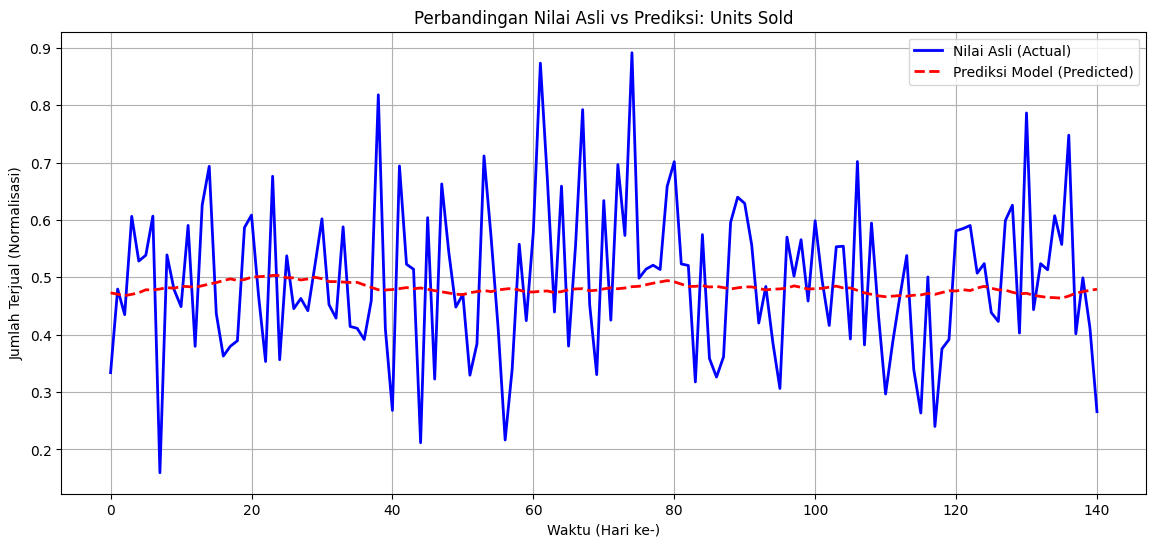

In [ ]:
# Visualisasi khusus untuk 'Units Sold' (Kamu bisa ganti indeks 0 ke 1 untuk melihat Inventory)
plt.figure(figsize=(14, 6))

# Plot data asli vs prediksi
plt.plot(y_test[:, 0], label='Nilai Asli (Actual)', color='blue', linewidth=2)
plt.plot(y_pred[:, 0], label='Prediksi Model (Predicted)', color='red', linestyle='dashed', linewidth=2)

plt.title('Perbandingan Nilai Asli vs Prediksi: Units Sold')
plt.xlabel('Waktu (Hari ke-)')
plt.ylabel('Jumlah Terjual (Normalisasi)')
plt.legend()
plt.grid(True)
plt.show()